In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rapidfuzz import process, fuzz
import re

In [2]:
# load song years scraped from wikipedia using beautiful soup in data wrangling notebook

song_years_scraped = pd.read_csv('song_years_all.csv')

In [3]:
song_years_scraped.head()

,year,source,confidence,Title
0,1941.0,https://en.wikipedia.org/wiki/9:20_Special,medium,9.20 Special
1,1960.0,https://en.wikipedia.org/wiki/26-2,medium,26-2
2,NaN,https://en.wikipedia.org/wiki/List_of_composit...,low,52nd Street Theme
3,1972.0,https://en.wikipedia.org/wiki/500_Miles_High,medium,500 Miles High
4,1958.0,https://en.wikipedia.org/wiki/502_Blues,medium,502 Blues


In [4]:
song_data = pd.read_csv('../data/song_data.csv')

In [5]:
song_data.head()

,Title,Composer,Rhythm,TimeSignature,Sections,Key,Year
0,9.20 Special,Earl Warren,Medium Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'D9|...",NaN,1941
1,26-2,John Coltrane,Medium Up Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Fma...",F,1947
2,52nd Street Theme,Thelonious Monk,Up Tempo Swing,4/4,"[{'Label': 'A', 'Repeats': 1, 'MainSegment': {...",NaN,1947
3,500 Miles High,Chick Corea,Bossa Nova,4/4,[{'MainSegment': {'Chords': 'Em7|Em7|Gm7|Gm7|B...,Emin,1972
4,502 Blues,Jimmy Rowles,Waltz,3/4,[{'MainSegment': {'Chords': 'Am7|Dbmaj7|Bm7b5|...,Amin,1959


In [6]:
song_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1382 entries, 0 to 1381
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Title          1382 non-null   object
 1   Composer       1382 non-null   object
 2   Rhythm         1382 non-null   object
 3   TimeSignature  1371 non-null   object
 4   Sections       1382 non-null   object
 5   Key            1149 non-null   object
 6   Year           1382 non-null   object
dtypes: object(7)
memory usage: 75.7+ KB


In [7]:
song_years_scraped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        1097 non-null   float64
 1   source      1308 non-null   object 
 2   confidence  1350 non-null   object 
 3   Title       1350 non-null   object 
dtypes: float64(1), object(3)
memory usage: 42.3+ KB


In [8]:
# only the first 1350 songs were webscraped for an updated year. There are 1382 songs in total
# copy Year column of song data to a new column (since last 32 entries will need to be the same)
song_data['Year_scraped'] = song_data['Year']

In [10]:
# Convert scraped years to integers (handling NaNs) before the lookup
year_lookup = song_years_scraped.set_index('Title')['year']
temp_years = song_data['Title'].map(year_lookup).fillna(song_data['Year_scraped'])

# 2. Convert to numeric, turning 'na' into NaN
song_data['Year_scraped'] = pd.to_numeric(temp_years, errors='coerce')

In [11]:
# cross referenced from this source:
# https://en.wikipedia.org/wiki/List_of_jazz_standards

#titles may not match those in song_years_scraped

wiki_source_ref = {
    # Pre-1920
    "Careless Love": 1900,
    "St. James Infirmary Blues": 1900,
    "When the Saints Go Marching In": 1900,
    "High Society": 1901,
    "Bill Bailey (Won't You Please Come Home)": 1902,
    "Chinatown, My Chinatown": 1910,
    "Some of These Days": 1910,
    "Alexander's Ragtime Band": 1911,
    "The Memphis Blues": 1912,
    "Ballin' the Jack": 1913,
    "St. Louis Blues": 1914,
    "That's a Plenty": 1914,
    "Twelfth Street Rag": 1914,
    "I Ain't Got Nobody": 1915,
    "Weary Blues": 1915,
    "Beale Street Blues": 1916,
    "Li'l Liza Jane": 1916,
    "Darktown Strutters' Ball": 1917,
    "Indiana": 1917,
    "Rose Room": 1917,
    "Tiger Rag": 1917,

    # 1920s
    "Avalon": 1920,
    "Margie": 1920,
    "The Jazz Me Blues": 1921,
    "The Sheik of Araby": 1921,
    "Bugle Call Rag": 1922,
    "China Boy": 1922,
    "Farewell Blues": 1922,
    "I Wish I Could Shimmy Like My Sister Kate": 1922,
    "Charleston": 1923,
    "Tin Roof Blues": 1923,
    "Everybody Loves My Baby": 1924,
    "Fascinating Rhythm": 1924,
    "Hard Hearted Hannah (The Vamp of Savannah)": 1924,
    "How Come You Do Me Like You Do?": 1924,
    "I'll See You in My Dreams": 1924,
    "King Porter Stomp": 1924,
    "The Man I Love": 1924,
    "Oh, Lady Be Good!": 1924,
    "Riverboat Shuffle": 1924,
    "Somebody Loves Me": 1924,
    "Dinah": 1925,
    "Don't Bring Lulu": 1925,
    "I Want to Be Happy": 1925,
    "Squeeze Me": 1925,
    "Sweet Georgia Brown": 1925,
    "Tea for Two": 1925,
    "Big Butter and Egg Man": 1926,
    "Bye Bye Blackbird": 1926,
    "'Deed I Do": 1926,
    "I Can't Believe That You're in Love with Me": 1926,
    "If I Could Be with You (One Hour Tonight)": 1926,
    "I've Found a New Baby": 1926,
    "Muskrat Ramble": 1926,
    "Someone to Watch Over Me": 1926,
    "Sugar": 1926,
    "Blue Skies": 1927,
    "'S Wonderful": 1927,
    "Basin Street Blues": 1928,
    "Crazy Rhythm": 1928,
    "Creole Love Call": 1928,
    "I Can't Give You Anything but Love, Baby": 1928,
    "If I Had You": 1928,
    "Lover, Come Back to Me": 1928,
    "Nagasaki": 1928,
    "Softly, As in a Morning Sunrise": 1928,
    "Sweet Lorraine": 1928,
    "Ain't Misbehavin'": 1929,
    "Black and Blue": 1929,
    "Honeysuckle Rose": 1929,
    "Just You, Just Me": 1929,
    "Liza (All the Clouds'll Roll Away)": 1929,
    "Mean to Me": 1929,
    "More Than You Know": 1929,
    "Rockin' Chair": 1929,
    "Stardust": 1929,
    "What Is This Thing Called Love?": 1929,

    # 1930s
    "Body and Soul": 1930,
    "But Not for Me": 1930,
    "Confessin' (That I Love You)": 1930,
    "Embraceable You": 1930,
    "Exactly Like You": 1930,
    "Georgia on My Mind": 1930,
    "I Got Rhythm": 1930,
    "Lazy River": 1930,
    "Memories of You": 1930,
    "Mood Indigo": 1930,
    "On the Sunny Side of the Street": 1930,
    "All of Me": 1931,
    "Beautiful Love": 1931,
    "I Surrender Dear": 1931,
    "Just Friends": 1931,
    "Out of Nowhere": 1931,
    "When It's Sleepy Time Down South": 1931,
    "When Your Lover Has Gone": 1931,
    "Alone Together": 1932,
    "April in Paris": 1932,
    "How Deep Is the Ocean? (How High Is the Sky?)": 1932,
    "I Don't Stand a Ghost of a Chance with You": 1932,
    "It Don't Mean a Thing (If It Ain't Got That Swing)": 1932,
    "Sophisticated Lady": 1933,
    "Smoke Gets in Your Eyes": 1933,
    "Stardust": 1933,
    "Summertime": 1935,
    "I Can't Get Started": 1935,
    "Caravan": 1936,
    "Stompin' at the Savoy": 1936,
    "There Is No Greater Love": 1936,
    "The Way You Look Tonight": 1936,
    "A Foggy Day": 1937,
    "Have You Met Miss Jones?": 1937,
    "My Funny Valentine": 1937,
    "Our Love Is Here to Stay": 1937,
    "Cherokee": 1938,
    "Prelude to a Kiss": 1938,
    "The Nearness of You": 1938,
    "All the Things You Are": 1939,
    "Darn That Dream": 1939,
    "I Thought About You": 1939,
    "Take the 'A' Train": 1939,
    "What's New?": 1939,

    # 1940s
    "After Hours": 1940,
    "All Too Soon": 1940,
    "Cotton Tail": 1940,
    "Do Nothing till You Hear from Me": 1940,
    "Don't Get Around Much Anymore": 1940,
    "How High the Moon": 1940,
    "In a Mellow Tone": 1940,
    "Polka Dots and Moonbeams": 1940,
    "You Stepped Out of a Dream": 1940,
    "Aquarela do Brasil": 1941,
    "Blues in the Night": 1941,
    "Chelsea Bridge": 1941,
    "Flamingo": 1941,
    "I Got It Bad (and That Ain't Good)": 1941,
    "I Hear a Rhapsody": 1941,
    "I'll Remember April": 1941,
    "Jim": 1941,
    "Just A‑Sittin' and A‑Rockin'": 1941,
    "Just Squeeze Me (But Please Don't Tease Me)": 1941,
    "Salt Peanuts": 1941,
    "Take the 'A' Train": 1941,
    "Why Don't You Do Right?": 1941,
    "You Don't Know What Love Is": 1941,
    "C Jam Blues": 1942,
    "Epistrophy": 1942,
    "Lover Man (Oh, Where Can You Be?)": 1942,
    "A Night in Tunisia": 1942,
    "Perdido": 1942,
    "Skylark": 1942,
    "That Old Black Magic": 1942,
    "There Will Never Be Another You": 1942,
    "Things Ain't What They Used to Be": 1942,
    "Woody 'n' You": 1942,
    "Harlem Nocturne": 1943,
    "Star Eyes": 1943,
    "The Surrey with the Fringe on Top": 1943,
    "Ev'ry Time We Say Goodbye": 1944,
    "Groovin' High": 1944,
    "I Fall in Love Too Easily": 1944,
    "I Should Care": 1944,
    "It Could Happen to You": 1944,
    "Long Ago (and Far Away)": 1944,
    "'Round Midnight": 1944,
    "Stella by Starlight": 1944,
    "Well, You Needn't": 1944,
    "Billie's Bounce": 1945,
    "Everything but You": 1945,
    "Hot House": 1945,
    "I'm Just a Lucky So-and-So": 1945,
    "It Might as Well Be Spring": 1945,
    "Laura": 1945,
    "Now's the Time": 1945,
    "Since I Fell for You": 1945,
    "I'll Close My Eyes": 1945,
    "Angel Eyes": 1946,
    "Anthropology": 1946,
    "Come Rain or Come Shine": 1946,
    "Confirmation": 1946,
    "Day Dream": 1946,
    "Do You Know What It Means to Miss New Orleans": 1946,
    "If You Could See Me Now": 1946,
    "Nobody Else But Me": 1946,
    "Ornithology": 1946,
    "Tenderly": 1946,
    "The Things We Did Last Summer": 1946,
    "Yardbird Suite": 1946,
    "Autumn Leaves": 1947,
    "But Beautiful": 1947,
    "C'est si bon": 1947,
    "Donna Lee": 1947,
    "In Walked Bud": 1947,
    "Lady Bird": 1947,
    "Nature Boy": 1947,
    "On Green Dolphin Street": 1947,
    "Our Delight": 1947,
    "Scrapple from the Apple": 1947,
    "Detour Ahead": 1948,
    "Four Brothers": 1948,
    "The Night Has a Thousand Eyes": 1948,
    "Lush Life": 1949,
    "My Foolish Heart": 1949,

    # Post-1950
    "If I Were a Bell": 1950,
    "Au Privave": 1951,
    "Blues for Alice": 1951,
    "Birks' Works": 1951,
    "Night Train": 1951,
    "Straight, No Chaser": 1951,
    "Bags' Groove": 1952,
    "Lullaby of Birdland": 1952,
    "My One and Only Love": 1952,
    "That's All": 1952,
    "When I Fall in Love": 1952,
    "Here's That Rainy Day": 1953,
    "Jordu": 1953,
    "Minority": 1953,
    "Airegin": 1954,
    "All of You": 1954,
    "Blue Monk": 1954,
    "Django": 1954,
    "Doxy": 1954,
    "Fly Me to the Moon": 1954,
    "Four": 1954,
    "Joy Spring": 1954,
    "Misty": 1954,
    "Oleo": 1954,
    "Solar": 1954,
    "In Your Own Sweet Way": 1955,
    "Canadian Sunset": 1956,
    "Con Alma": 1956,
    "Nica's Dream": 1956,
    "St. Thomas": 1956,
    "Waltz for Debby": 1956,
    "Whisper Not": 1956,
    "Blue Train": 1957,
    "I Remember Clifford": 1957,
    "Li'l Darlin'": 1957,
    "Soul Eyes": 1957,
    "Chega de Saudade": 1958,
    "Milestones": 1958,
    "Moanin'": 1958,
    "Vishnu": 1958,
    "Afro Blue": 1959,
    "All Blues": 1959,
    "The Best Is Yet to Come": 1959,
    "Blue in Green": 1959,
    "Desafinado": 1959,
    "Freddie Freeloader": 1959,
    "Giant Steps": 1959,
    "Countdown": 1959,
    "Goodbye Pork Pie Hat": 1959,
    "Goodbye Tristesse": 1959,
    "Killer Joe": 1959,
    "Manhã de Carnaval": 1959,
    "Mr. P.C.": 1959,
    "My Favorite Things": 1959,
    "Naima": 1959,
    "Nostalgia in Times Square": 1959,
    "The Sidewinder": 1959,
    "So What": 1959,
    "Take Five": 1959,
    "Jeannine": 1960,
    "Impressions": 1961,
    "Once I Loved": 1961,
    "One Note Samba": 1961,
    "Stolen Moments": 1961,
    "Corcovado": 1962,
    "Days of Wine and Roses": 1962,
    "Meditation": 1962,
    "Up Jumped Spring": 1962,
    "Blue Bossa": 1963,
    "Bluesette": 1963,
    "The Girl from Ipanema": 1963,
    "How Insensitive": 1963,
    "If You Never Come to Me": 1963,
    "Oye Como Va": 1963,
    "Recorda Me": 1963,
    "Só Danço Samba": 1963,
    "Water to Drink": 1963,
    "Watermelon Man": 1963,
    "Cantaloupe Island": 1964,
    "Inner Urge": 1964
}


In [12]:
song_data.head()

,Title,Composer,Rhythm,TimeSignature,Sections,Key,Year,Year_scraped
0,9.20 Special,Earl Warren,Medium Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'D9|...",NaN,1941,1941.0
1,26-2,John Coltrane,Medium Up Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Fma...",F,1947,1960.0
2,52nd Street Theme,Thelonious Monk,Up Tempo Swing,4/4,"[{'Label': 'A', 'Repeats': 1, 'MainSegment': {...",NaN,1947,1947.0
3,500 Miles High,Chick Corea,Bossa Nova,4/4,[{'MainSegment': {'Chords': 'Em7|Em7|Gm7|Gm7|B...,Emin,1972,1972.0
4,502 Blues,Jimmy Rowles,Waltz,3/4,[{'MainSegment': {'Chords': 'Am7|Dbmaj7|Bm7b5|...,Amin,1959,1958.0


In [13]:
import re
from rapidfuzz import process, fuzz 

# 1. Optimized Cleaning Function
def clean_title(title):
    if not isinstance(title, str): return ""
    title = title.lower()
    title = re.sub(r"\(.*?\)", "", title)      # Remove parentheses content
    title = re.sub(r"[^a-z0-9\s]", "", title)  # Remove punctuation
    return " ".join(title.split())             # Faster way to handle extra spaces

# 2. Vectorized Preparation
clean_dict = {clean_title(k): v for k, v in wiki_source_ref.items()}
dict_titles = list(clean_dict.keys())
song_data["clean_title"] = song_data["Title"].apply(clean_title)

# 3. Streamlined Matching Function
def find_year(title):
    # Try exact match first (O(1) speed)
    if title in clean_dict:
        return clean_dict[title], "exact"
    
    # Fuzzy fallback (Only if exact fails)
    match = process.extractOne(title, dict_titles, scorer=fuzz.token_sort_ratio)
    if match and match[1] >= 90:
        return clean_dict[match[0]], "fuzzy"
    
    return None, None

# 4. Apply & Expand in one step
# Using result_type='expand' turns the (year, type) tuple into two columns immediately
song_data[['correct_year', 'match_type']] = song_data['clean_title'].apply(
    lambda x: pd.Series(find_year(x))
)

In [14]:
song_data.head()

,Title,Composer,Rhythm,TimeSignature,Sections,Key,Year,Year_scraped,clean_title,correct_year,match_type
0,9.20 Special,Earl Warren,Medium Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'D9|...",NaN,1941,1941.0,920 special,NaN,None
1,26-2,John Coltrane,Medium Up Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Fma...",F,1947,1960.0,262,NaN,None
2,52nd Street Theme,Thelonious Monk,Up Tempo Swing,4/4,"[{'Label': 'A', 'Repeats': 1, 'MainSegment': {...",NaN,1947,1947.0,52nd street theme,NaN,None
3,500 Miles High,Chick Corea,Bossa Nova,4/4,[{'MainSegment': {'Chords': 'Em7|Em7|Gm7|Gm7|B...,Emin,1972,1972.0,500 miles high,NaN,None
4,502 Blues,Jimmy Rowles,Waltz,3/4,[{'MainSegment': {'Chords': 'Am7|Dbmaj7|Bm7b5|...,Amin,1959,1958.0,502 blues,NaN,None


In [15]:
song_data[song_data['correct_year'].notna()].head()

,Title,Composer,Rhythm,TimeSignature,Sections,Key,Year,Year_scraped,clean_title,correct_year,match_type
13,A Foggy Day,George Gershwin,Medium Swing,4/4,"[{'Label': 'v', 'MainSegment': {'Chords': 'Fma...",F,1937,1937.0,a foggy day,1937.0,exact
18,A Night In Tunisia,Dizzy Gillespie,Latin,4/4,"[{'Label': 'A', 'Repeats': 1, 'MainSegment': {...",Dmin,1944,1942.0,a night in tunisia,1942.0,exact
37,Afro Blue,Mongo Santamaria,Waltz,3/4,"[{'MainSegment': {'Chords': 'Fm7|Fm7|Db7#9/Ab,...",Fmin,1959,1959.0,afro blue,1959.0,exact
45,Ain't Misbehavin',Fats Waller,Medium Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'C6,...",NaN,1927,1929.0,aint misbehavin,1929.0,exact
47,Airegin,Sonny Rollins,Up Tempo Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Fm|...",Fmin,1954,1954.0,airegin,1954.0,exact


In [17]:
# 5. Final Update & Flagging
# We use .fillna() to keep original years where no match was found
song_data["correct_year"] = song_data["correct_year"].fillna(song_data["Year_scraped"])

In [19]:
song_data[song_data['match_type']=='exact'].head()

,Title,Composer,Rhythm,TimeSignature,Sections,Key,Year,Year_scraped,clean_title,correct_year,match_type
13,A Foggy Day,George Gershwin,Medium Swing,4/4,"[{'Label': 'v', 'MainSegment': {'Chords': 'Fma...",F,1937,1937.0,a foggy day,1937.0,exact
18,A Night In Tunisia,Dizzy Gillespie,Latin,4/4,"[{'Label': 'A', 'Repeats': 1, 'MainSegment': {...",Dmin,1944,1942.0,a night in tunisia,1942.0,exact
37,Afro Blue,Mongo Santamaria,Waltz,3/4,"[{'MainSegment': {'Chords': 'Fm7|Fm7|Db7#9/Ab,...",Fmin,1959,1959.0,afro blue,1959.0,exact
45,Ain't Misbehavin',Fats Waller,Medium Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'C6,...",NaN,1927,1929.0,aint misbehavin,1929.0,exact
47,Airegin,Sonny Rollins,Up Tempo Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Fm|...",Fmin,1954,1954.0,airegin,1954.0,exact


In [20]:
song_data.describe()

,Year_scraped,correct_year
count,1362.000000,1362.000000
mean,1956.858297,1955.680617
std,31.115481,30.076098
min,1807.000000,1807.000000
25%,1938.000000,1937.000000
50%,1955.000000,1954.000000
75%,1973.750000,1969.750000
max,2026.000000,2026.000000


In [21]:
(song_data['correct_year'] == 'na').sum()

np.int64(0)

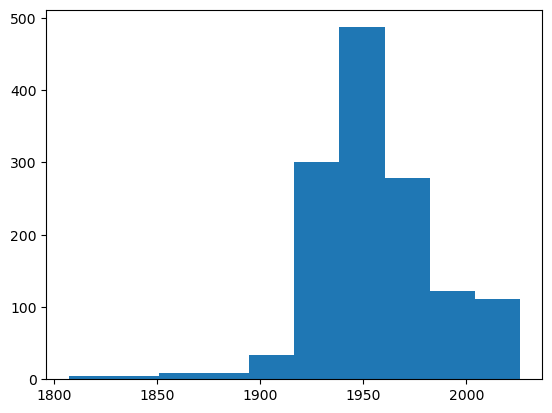

In [22]:
plt.hist(pd.to_numeric(song_data['correct_year'], errors='coerce'))
plt.show()

In [23]:
song_data['correct_year'] = pd.to_numeric(song_data['correct_year'], errors='coerce')

In [24]:
(song_data['correct_year'] > 1970).sum()

np.int64(334)

In [25]:
# 334 songs are later than 1970 - many of these are wrong because the scraping found a wiki page that was not the song (sometimes a movie etc)
# We will now start the process of manually googling and correcting these
song_list = song_data.loc[song_data['correct_year'] > 1970, 'clean_title'].tolist()

In [26]:
print(song_list)

['500 miles high', 'a shade of jade', 'a smooth one', 'a sound for sore ears', 'adams apple', 'affirmation', 'afro centric', 'after you', 'again', 'ahmid6', 'airmail special', 'all alone', 'all at once you love her', 'all by myself', 'alone too long', 'along came betty', 'always', 'always and forever', 'and on the third day', 'april joy', 'april skies', 'at long last love', 'autumn in new york', 'autumn nocturne', 'balance the', 'baltimore oriole', 'barbara', 'be careful its my heart', 'be my love', 'beatrice', 'bennys tune', 'best thing for you is me the', 'better days ahead', 'beyond the sea', 'blackberry winter', 'blue', 'blue room the', 'blue silver', 'blue sphere', 'boo boos birthday', 'born to be blue', 'boulevard of broken dreams the', 'boy next door the', 'bright boy', 'bright mississippi', 'bright size life', 'brotherhood of man', 'butterfly dreams', 'by myself', 'cta', 'call me', 'call me irresponsible', 'cant we be friends', 'captain marvel', 'catch me', 'central park west',

In [28]:
# create strings to copy and paste into google (10 or 15 at a time)

for song in song_list:
    # Use .iloc[0] to get just the string value of the first match
    composer = song_data.loc[song_data['clean_title'] == song, 'Composer'].iloc[0]
    
    print(f"what year was the jazz standard '{song}' by {composer} written")

what year was the jazz standard '500 miles high' by Chick Corea written
what year was the jazz standard 'a shade of jade' by Joe Henderson written
what year was the jazz standard 'a smooth one' by Benny Goodman written
what year was the jazz standard 'a sound for sore ears' by Jimmy Heath written
what year was the jazz standard 'adams apple' by Wayne Shorter written
what year was the jazz standard 'affirmation' by José Feliciano written
what year was the jazz standard 'afro centric' by Joe Henderson written
what year was the jazz standard 'after you' by Cole Porter written
what year was the jazz standard 'again' by Lionel Newman written
what year was the jazz standard 'ahmid6' by Pat Metheny written
what year was the jazz standard 'airmail special' by Charlie Christian written
what year was the jazz standard 'all alone' by Irving Berlin written
what year was the jazz standard 'all at once you love her' by Rodgers-Hammerstein written
what year was the jazz standard 'all by myself' by Ir

In [29]:
manual_corrections = {
    "a smooth one": 1941,
    "a sound for sore ears": 1982,
    "again": 1948,
    "airmail special": 1941,
    "alfies theme": 1966,
    "all alone": 1924,
    "all at once you love her": 1955,
    "all by myself": 1921,
    "alone too long": 1924,
    "along came betty": 1958,
    "always and forever": 1992,
    "april joy": 1982,
    "april skies": 1952,
    "at long last love": 1938,
    "autumn in new york": 1934,
    "autumn nocturne": 1941,
    "balance the": 1998,
    "baltimore oriole": 1942,
    "be careful its my heart": 1942,
    "be my love": 1950,
    "beatrice": 1964,
    "bennys tune": 2005,
    "best thing for you is me the": 1950,
    "beyond the sea": 1943,
    "blackberry winter": 1976,
    "blue": 1922,
    "blue room the": 1926,
    "blue silver": 1957,
    "blue sphere": 1971,
    "boo boos birthday": 1967,
    "born to be blue": 1946,
	"boulevard of broken dreams the": 1933,
	"boy next door the": 1944,
	"bright boy": 1955,
	"bright mississippi": 1962,
	"bright size life": 1973,
	"brotherhood of man": 1961,
	"butterfly dreams": 1973,
	"by myself": 1937,
	"cta": 1953,
	"call me": 1965,
	"call me irresponsible": 1962,
	"cant we be friends": 1929,
	"captain marvel": 1972,
	"catch me": 1963,
	"central park west": 1960,
	"chameleon": 1973,
	"chase the": 1947,
	"cheers": 1948,
	"cheetah": 1957,
	"cheryl": 1947,
	"chicago": 1922,
	"chicken the": 1969,
	"chucho": 1979,
	"close enough for love": 1979,
	"close your eyes": 1933,
	"cold duck time": 1969,
	"come fly with me": 1957,
	"comes love": 1939,
	"comrade conrad": 1971,
	"conference of the birds": 1972,
	"continuum": 1975,
	"core the": 1964,
	"could it be you": 1943,
	"country": 1977,
	"crystal silence": 1972,
	"cyclic episode": 1964,
	"dancing in the dark": 1931,
	"dancing on the ceiling": 1930,
	"day by day": 1945,
	"day waves": 1972,
	"days and nights waiting": 1967,
	"dienda": 1986,
	"do it again": 1922,
	"dolphin the": 1970,
	"dont be that way": 1934,
	"dont blame me": 1932,
	"dont know why": 1999,
	"dont worry bout me": 1938,
	"down for double": 1941,
	"dreamsville": 1958,
	"east of the sun": 1934,
	"eclypso": 1977,
	"el cajon": 1985,
	"elora": 1949,
	"emily": 1964,
	"end of a love affair the": 1950,
	"epilogue": 1959,
	"eternal triangle": 1957,
	"everything i love": 1941,
	"everything ive got belongs to you": 1942,
	"falling grace": 1965,
	"falling in love again": 1930,
	"favela": 1962,
	"feels so good": 1977,
	"firm roots": 1974,
	"five brothers": 1949,
	"fools rush in": 1940,
	"for all we know": 1934,
	"forever sonny": 1992,
	"four in one": 1951,
	"four on six": 1960,
	"frim fram sauce the": 1945,
	"from this moment on": 1950,
	"full house": 1962,
	"funk in deep freeze": 1957,
	"gentle wind and falling tear": 1963,
	"girl talk": 1965,
	"good life the": 1962,
	"got a match": 1986,
	"grand central": 1959,
	"green chimneys": 1966,
	"h h": 1990,
	"haunted heart": 1948,
	"heat wave": 1933,
	"heres that sunny day": 1975,
	"heres to life": 1990,
	"heres to my lady": 1951,
	"heyoke": 1975,
	"high fly": 1958,
	"high hopes": 1959,
	"hocuspocus": 1963,
	"home at last": 1970,
	"home cookin": 1957,
	"homecoming": 1994,
	"house of jade": 1964,
	"how about you": 1941,
	"i dont know enough about you": 1945,
	"i feel pretty": 1956,
	"i get along without you": 1938,
	"i hear music": 1940,
	"i like the likes of you": 1933,
	"i may be wrong": 1929,
	"i think of you": 1941,
	"i want to talk about you": 1944,
	"ill be around": 1942,
	"im in the mood for love": 1935,
	"if i ruled the world": 1963,
	"if you ever should leave": 1937,
	"in her family": 1987,
	"in pursuit of the 27th man": 1972,
	"in the middle of a kiss": 1935,
	"in the still of the night": 1937,
	"infant eyes": 1964,
	"is that so": 1966,
	"isnt it romantic": 1932,
	"isnt this a lovely day": 1935,
	"it was so good while it lasted": 1948,
	"its a good day": 1946,
	"its delovely": 1936,
	"its just talk": 1987,
	"je ne sais pas": 1954,
	"jeepers creepers": 1938,
	"just in time": 1956,
	"just one more chance": 1931,
	"katrina ballerina": 1981,
	"kids are pretty people": 1968,
	"ko ko": 1945,
	"love": 1964,
	"la fiesta": 1971,
	"lady sings the blues": 1956,
	"lakes": 1977,
	"last train home": 1987,
	"leaving": 1976,
	"lennies pennies": 1949,
	"let there be love": 1940,
	"let there be you": 1956,
	"lets get lost": 1943,
	"like a lover": 1965,
	"limbo": 1967,
	"line for lyons": 1952,
	"litha": 1966,
	"little peace in c for you": 1990,
	"little willie leaps": 1947,
	"lonely dreams": 1955,
	"long ago and far away": 1944,
	"look to the sky": 1967,
	"looking up": 1985,
	"loop the": 1971,
	"love walked in": 1930,
	"ma belle hlne": 1990,
	"mahjong": 1964,
	"make someone happy": 1960,
	"masquerade is over the": 1939,
	"maybe september": 1965,
	"mc jolt": 1989,
	"memories of tomorrow": 1969,
	"milano": 1954,
	"mimosa": 1982,
	"minoat": 1978,
	"minor strain": 1960,
	"mirror mirror": 1980,
	"miyako": 1967,
	"moon and sand": 1941,
	"moon mist": 1941,
	"moon rays": 1958,
	"moonchild": 1970,
	"moonglow": 1933,
	"moontrane the": 1974,
	"most beautiful girl in the world the": 1935,
	"move": 1948,
	"my ideal": 1930,
	"my lucky star": 1928,
	"my romance": 1935,
	"my secret love": 1986,
	"my song": 1977,
	"nacada": 1977,
	"nascimento": 1996,
	"never let me go": 1953,
	"new picture": 1985,
	"new york new york": 1977,
	"nice work if you can get it": 1937,
	"night we called it a day the": 1941,
	"nothing personal": 1987,
	"nutty": 1954,
	"off minor": 1947,
	"old country the": 1960,
	"on a clear day": 1965,
	"on a misty night": 1956,
	"on broadway": 1962,
	"one by one": 1962,
	"one finger snap": 1964,
	"ps i love you": 1934,
	"partys over the": 1956,
	"passion dance": 1967,
	"peacocks the": 1974,
	"pee wee": 1967,
	"pennies from heaven": 1936,
	"people": 1963,
	"pfrancing": 1961,
	"phase dance": 1978,
	"ping pong": 1961,
	"played twice": 1959,
	"polkadots and moonbeams": 1940,
	"popsicle toes": 1975,
	"pretend": 1952,
	"prince of darkness": 1967,
	"prism": 1979,
	"progression": 1949,
	"pure imagination": 1971,
	"questar": 1977,
	"question and answer": 1989,
	"rainbow connection the": 1979,
	"re person i knew": 1974,
	"recordame": 1957,
	"red clay": 1970,
	"room 608": 1954,
	"rosetta": 1939,
	"sos": 1962,
	"saga of harrison crabfeathers the": 1972,
	"sail away": 1989,
	"sandu": 1955,
	"save your love for me": 1955,
	"say it": 1940,
	"say the brothers name": 1994,
	"sea journey": 1971,
	"search for peace": 1967,
	"second star to the right the": 1951,
	"september song": 1938,
	"serenity": 1964,
	"seven come eleven": 1939,
	"shes funny that way": 1928,
	"shine": 1910,
	"shutterbug": 1960,
	"simone": 1977,
	"sippin at bells": 1947,
	"sno peas": 1979,
	"some other time": 1944,
	"sometime ago": 1962,
	"somewhere": 1957,
	"song for my lady": 1972,
	"soon": 1929,
	"spain": 1971,
	"speak no evil": 1964,
	"spiral": 1959,
	"stairway to the stars": 1935,
	"street of dreams": 1932,
	"strollin": 1960,
	"summer band camp": 1978,
	"summer in central park": 1972,
	"summer knows the": 1971,
	"summer night": 1935,
	"summer serenade": 1980,
	"sun down": 1966,
	"sweet georgia bright": 1964,
	"tell me a bedtime story": 1969,
	"that old feeling": 1937,
	"thats life": 1963,
	"theme from family guy": 1999,
	"these foolish things": 1936,
	"they all laughed": 1937,
	"think of one": 1954,
	"this cant be love": 1938,
	"this is new": 1941,
	"this masquerade": 1972,
	"time after time": 1946,
	"too close for comfort": 1956,
	"too young": 1951,
	"tranes blues": 1956,
	"travels": 1982,
	"triste": 1966,
	"turn out the stars": 1966,
	"twisted": 1949,
	"twisted blues": 1965,
	"two not one": 1949,
	"ugly beauty": 1967,
	"unforgettable": 1951,
	"unity village": 1976,
	"very early": 1962,
	"voyage": 1986,
	"walk tall": 1967,
	"warm valley": 1940,
	"watch what happens": 1964,
	"waynes thang": 1995,
	"we see": 1954,
	"we will meet again": 1977,
	"wendy": 1975,
	"when it rains": 2001,
	"while were young": 1943,
	"wild flower": 1964,
	"windows": 1966,
	"without a song": 1929,
	"yesterdays gardenias": 1942,
	"youre everything": 1972
}

In [30]:
for title, correct_year in manual_corrections.items():
    song_data.loc[
        song_data['clean_title'] == title, 
        ['correct_year', 'match_type']
    ] = [float(correct_year), 'manual_fix']

In [33]:
song_data.head(30)

,Title,Composer,Rhythm,TimeSignature,Sections,Key,Year,Year_scraped,clean_title,correct_year,match_type
0,9.20 Special,Earl Warren,Medium Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'D9|...",NaN,1941,1941.0,920 special,1941.0,None
1,26-2,John Coltrane,Medium Up Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Fma...",F,1947,1960.0,262,1960.0,None
2,52nd Street Theme,Thelonious Monk,Up Tempo Swing,4/4,"[{'Label': 'A', 'Repeats': 1, 'MainSegment': {...",NaN,1947,1947.0,52nd street theme,1947.0,None
3,500 Miles High,Chick Corea,Bossa Nova,4/4,[{'MainSegment': {'Chords': 'Em7|Em7|Gm7|Gm7|B...,Emin,1972,1972.0,500 miles high,1972.0,None
4,502 Blues,Jimmy Rowles,Waltz,3/4,[{'MainSegment': {'Chords': 'Am7|Dbmaj7|Bm7b5|...,Amin,1959,1958.0,502 blues,1958.0,None
5,A Ballad,Gerry Mulligan,Ballad,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Dm7...",NaN,na,NaN,a ballad,NaN,None
6,A Beautiful Friendship,Donald Kahn,Medium Swing,4/4,"[{'Label': 'A', 'Repeats': 1, 'MainSegment': {...",NaN,1956,1942.0,a beautiful friendship,1942.0,None
7,A Blossom Fell,Barnes-Cornelius,Ballad,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Bb6...",Bb,1955,1954.0,a blossom fell,1954.0,None
8,A Certain Smile,Fain-Webster,Medium Swing,4/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Gm7...",F,1958,1958.0,a certain smile,1958.0,None
9,A Child Is Born,Roland Hanna,Waltz,3/4,"[{'Label': 'A', 'MainSegment': {'Chords': 'Bbm...",Bb,1969,1965.0,a child is born,1965.0,None


In [34]:
song_data['Year'] = song_data['correct_year']

In [36]:
song_data = song_data.drop(columns=['Year_scraped', 'clean_title', 'correct_year', 'match_type'])

In [38]:
song_data.to_csv(
    "../data/song_data.csv",
    index=False
)

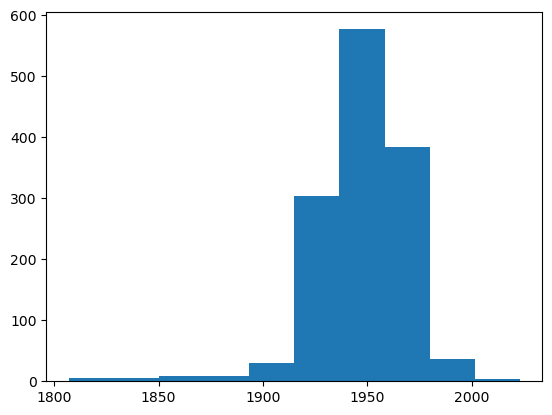

In [39]:
plt.hist(pd.to_numeric(song_data['Year'], errors='coerce'))
plt.show()